In [25]:
import easyocr
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
import json

# Detect point sur la feuille de marquage

In [26]:
def detect_point_column(image_path):
    # Lire l'image
    image = cv2.imread(image_path)

    # Convertir l'image en niveaux de gris
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Utiliser EasyOCR pour extraire le texte de l'image
    reader = easyocr.Reader(['fr'])  # Spécifiez la langue, par exemple 'fr' pour le français
    result = reader.readtext(gray)

    # Afficher le texte extrait (pour débogage)
    print("Texte extrait de l'image :")
    for (bbox, text, prob) in result:
        print(f"Texte: {text}, Probabilité: {prob}, Bounding box: {bbox}")
    return result

In [27]:
path = '..\data\externe\Feuille_de_marquage-page-001.jpeg'
result = detect_point_column(path)

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.
C:\Users\Nathan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\easyocr\detection.py:78: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case w

Texte extrait de l'image :
Texte: FEDERATION NATIONALE DES ANCIENS COMBATTANTS, Probabilité: 0.8872050421105464, Bounding box: [[362, 73], [1147, 73], [1147, 117], [362, 117]]
Texte: ALGERIE, Probabilité: 0.8797579357137394, Bounding box: [[553, 115], [685, 115], [685, 151], [553, 151]]
Texte: MAROC, Probabilité: 0.9995473155851005, Bounding box: [[704, 118], [814, 118], [814, 150], [704, 150]]
Texte: TUNISIE, Probabilité: 0.9995029377064341, Bounding box: [[830, 111], [953, 111], [953, 150], [830, 150]]
Texte:  , Probabilité: 0.026304437720805263, Bounding box: [[135, 114], [172, 114], [172, 229], [135, 229]]
Texte: Comite do Morsang sur Orge, Probabilité: 0.7039633222191556, Bounding box: [[565, 149], [942, 149], [942, 191], [565, 191]]
Texte: sieve social, Probabilité: 0.17380690584185793, Bounding box: [[528, 190], [646, 190], [646, 218], [528, 218]]
Texte: Malrle, 01300 Morsano aur Orge, Probabilité: 0.22112516214761982, Bounding box: [[657, 185], [980, 185], [980, 218], [657, 218

# Visualisez les donnée

Texte: FEDERATION NATIONALE DES ANCIENS COMBATTANTS, Probabilité: 0.8872050421105464, Bounding box: [[362, 73], [1147, 73], [1147, 117], [362, 117]]
Texte: ALGERIE, Probabilité: 0.8797579357137394, Bounding box: [[553, 115], [685, 115], [685, 151], [553, 151]]
Texte: MAROC, Probabilité: 0.9995473155851005, Bounding box: [[704, 118], [814, 118], [814, 150], [704, 150]]
Texte: TUNISIE, Probabilité: 0.9995029377064341, Bounding box: [[830, 111], [953, 111], [953, 150], [830, 150]]
Texte:  , Probabilité: 0.026304437720805263, Bounding box: [[135, 114], [172, 114], [172, 229], [135, 229]]
Texte: Comite do Morsang sur Orge, Probabilité: 0.7039633222191556, Bounding box: [[565, 149], [942, 149], [942, 191], [565, 191]]
Texte: sieve social, Probabilité: 0.17380690584185793, Bounding box: [[528, 190], [646, 190], [646, 218], [528, 218]]
Texte: Malrle, 01300 Morsano aur Orge, Probabilité: 0.22112516214761982, Bounding box: [[657, 185], [980, 185], [980, 218], [657, 218]]
Texte: (n, Probabilité: 

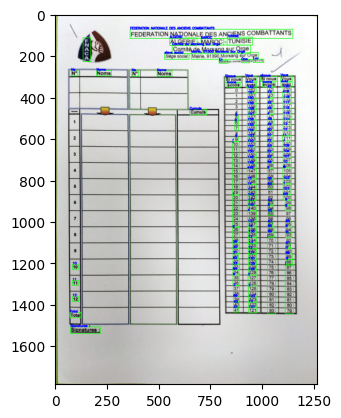

In [28]:
image = cv2.imread(path)
#TODO: rognez l'image pour ne garder que la partie qui nous intéresse
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

for (bbox, text, prob) in result:
    print(f"Texte: {text}, Probabilité: {prob}, Bounding box: {bbox}")
    
    # Convertir les coordonnées en tuples d'entiers
    top_left = tuple(map(int, bbox[0]))
    bottom_right = tuple(map(int, bbox[2]))
    
    # Dessiner la bounding box sur l'image
    image = cv2.rectangle(image, top_left, bottom_right, (0, 255, 0), 2)
    image = cv2.putText(image, text, top_left, cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2, cv2.LINE_AA)

# Afficher l'image avec les bounding boxes
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.show()

# Decoupe l'images en cases

Failed to delete ../data/externe/contours/points. Reason: [WinError 145] Le répertoire n’est pas vide: '../data/externe/contours/points'
Nombre de contours détectés: 2049
Nombre de contours: 300


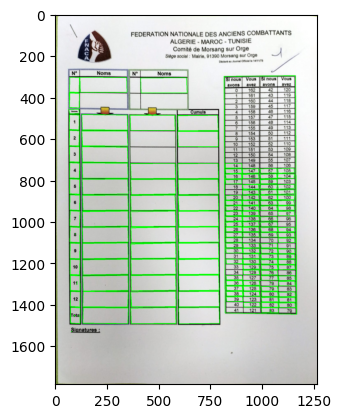

In [29]:
def delete_files(path):
    for filename in os.listdir(path_sauvegarde):
        file_path = os.path.join(path_sauvegarde, filename)
        try:
            if os.path.isfile(file_path) or os.path.islink(file_path):
                os.remove(file_path)
            elif os.path.isdir(file_path):
                os.rmdir(file_path)
        except Exception as e:
            print(f'Failed to delete {file_path}. Reason: {e}')

def detect_contours(frame, index, hierarhie, path):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edged = cv2.Canny(blurred, 30, 150)
    contours, hierarchy = cv2.findContours(edged.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    
    print(f"Nombre de contours détectés: {len(contours)}")

    # Convertir les contours en une structure sérialisable
    contours_list = [contour.tolist() for contour in contours]
    hierarchy_list = hierarchy[0].tolist() if hierarchy is not None else []

    # Créer un dictionnaire pour stocker les contours et la hiérarchie
    data = {
        "contours": contours_list,
        "hierarchy": hierarchy_list
    }

    # Enregistrer dans un fichier JSON
    with open(path + f'_hierarchy_{index}_{hierarhie}.json', 'w') as json_file:
        json.dump(data, json_file, indent=4)

    # Afficher uniquement les trois premiers contours de la hiérarchie
    count = 0
    for i, contour in enumerate(contours):
        if count >= index:
            break
        if hierarchy[0][i][3] <= hierarhie:  # Vérifie si le contour est un contour de niveau supérieur
            peri = cv2.arcLength(contour, True)
            approx = cv2.approxPolyDP(contour, 0.02 * peri, True)
            if len(approx) == 4:  # Vérifie si le contour est approximativement un rectangle
                cv2.drawContours(frame, [approx], -1, (0, 255, 0), 2)
                count += 1

                # Obtenir le rectangle englobant
                x, y, w, h = cv2.boundingRect(contour)
                # Découper la partie de l'image
                roi = frame[y:y+h, x:x+w]
                # Enregistrer la partie de l'image
                cv2.imwrite(path + f'_{x}_{y}_{h}_{w}.png', roi)
    
    print(f"Nombre de contours: {count}")
    return frame

# Construit le chemin complet de l'image
frame = cv2.imread(path)
path_sauvegarde = '../data/externe/contours/'
delete_files(path_sauvegarde)
frame_with_contours = detect_contours(frame, 300, 2000, path_sauvegarde)
plt.imshow(cv2.cvtColor(frame_with_contours, cv2.COLOR_BGR2RGB))  # Applique la détection de contours
plt.show()
# cv2.imwrite('output.png', frame_with_contours)  # Sauvegarde l'image avec contours

## Repere ou sont les mots "point" sur la grande image

In [30]:
# Initialiser le compteur
compteur_detection = 0
mot_dection = 'Point'
mot_exclu =  ['Point Cumulée', 'Point Cumules']

# Initialiser la liste pour stocker les coordonnées des points
dection_points = []

for (bbox, text, prob) in result:
    if mot_dection in text.split(" ")[0] and prob > 0.5 and text not in mot_exclu:
        compteur_detection += 1
        # Transforme le bbox en tuple (x, y, w, h)
        bbox = (bbox[0][0], bbox[0][1], bbox[2][0] - bbox[0][0], bbox[2][1] - bbox[0][1])

        dection_points.append({'texte': text, 'bbox': bbox})

    if compteur_detection == 4:
        break

print(f"Nombre de points détectés: {compteur_detection}")
print("Coordonnées des points détectés:" + str(dection_points))

Nombre de points détectés: 0
Coordonnées des points détectés:[]


## Repere ou sont les mots point sur la petite image

In [31]:
# Tolérance pour la comparaison des coordonnées
tolerance_x = 50
tolerance_y = 20
tolerance_w = 20
tolerance_h = 80

list_points = []

# Fonction pour extraire les coordonnées du nom de fichier
def extraire_coordonnees(nom_fichier):
    try:
        # Enlever l'extension du fichier
        nom_fichier_sans_extension = os.path.splitext(nom_fichier)[0]
        # Supposer que le nom de fichier est de la forme _x_y_w_h
        _, x, y, w, h = nom_fichier_sans_extension.split('_')
        return int(x), int(y), int(w), int(h)
    except ValueError:
        return None

# Fonction pour comparer les coordonnées avec tolérance
def comparer_coordonnees(coord1, coord2, tol_x, tol_y, tol_w, tol_h):
    x1, y1, w1, h1 = coord1
    x2, y2, w2, h2 = coord2
    return (abs(x1 - x2) <= tol_x and
            abs(y1 - y2) <= tol_y and
            abs(w1 - w2) <= tol_w and
            abs(h1 - h2) <= tol_h)

# Parcourir les fichiers dans le répertoire
for file in os.listdir(path_sauvegarde):
    if file.endswith('.png'):
        # Extraire les coordonnées du nom de fichier
        coordonnees = extraire_coordonnees(file)
        if coordonnees:
            # Comparer les coordonnées extraites avec celles des points détectés
            for point in dection_points:
                if comparer_coordonnees(point['bbox'], coordonnees, tolerance_x, tolerance_y, tolerance_w, tolerance_h):
                    list_points.append({'texte': point['texte'], 'position': coordonnees, 'image': file})
                    break  # Sortir de la boucle dès qu'un point est trouvé

print(list_points)

[]


## Verification des petites images pour les points

In [32]:
check_header_points = []
# Afficher les images correspondantes
for point in list_points:
    chemin_image = os.path.join(path_sauvegarde, point['image'])
    image_lue = cv2.imread(chemin_image)
    
    # Vérifier si l'image a été correctement lue
    if image_lue is None:
        print(f"Erreur : Impossible de lire le fichier {chemin_image}.")
        continue

    verify_result= detect_point_column(chemin_image)
    for (bbox, text, prob) in verify_result:
        if mot_dection in text.split(" ")[0] and prob > 0.5 and text not in mot_exclu:
            check_header_points.append(point)
    
    
    plt.imshow(cv2.cvtColor(image_lue, cv2.COLOR_BGR2RGB))
    plt.show()
    print(check_header_points)

## Recupérer les images en desous des headers_points

In [33]:
image_points= []

for file in os.listdir(path_sauvegarde):
    if file.endswith('.png'):
        # Extraire les coordonnées du nom de fichier
        coordonnees = extraire_coordonnees(file)
        if coordonnees:
            # Comparer les coordonnées extraites avec celles des points détectés
            for point in check_header_points:
                if point["position"][0] == coordonnees[0] and point["position"] != coordonnees and point["position"][1] < coordonnees[1]:
                    image_points.append({'texte': "", 'position': coordonnees, 'image': file})
                    break

print(image_points)
print(len(image_points))

[]
0


In [34]:
# Deplace les images dans un dossier

path_images_point= os.path.join(path_sauvegarde, 'points')
if not os.path.exists(path_images_point):
    os.makedirs(path_images_point)

for point in image_points:
    chemin_image = os.path.join(path_sauvegarde, point['image'])
    os.replace(chemin_image, os.path.join(path_images_point, point['image']))